# Trabajo Práctico N°6 de TPS: KMeans

En este trabajo práctico se implementa el algoritmo K-Means desde cero y se aplica a dos problemas:

- **Parte 1**: Compresión de una imagen a 16 colores. Cada píxel es tratado como una muestra en el espacio RGB y se reemplaza por el centroide más cercano de los 16 aprendidos.
- **Parte 2**: Caracterización de patrones de consumo eléctrico diario en hogares de Buenos Aires. Las señales de 24 horas se agrupan en 3 clusters para identificar perfiles típicos de consumo.

En primer lugar, se importan las librerías que se utilizarán a lo largo del mismo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Punto 1: Compresión de Imagen

### Inciso A

Se carga la imagen `goku_vs_piccolo.jpeg` y se grafica.

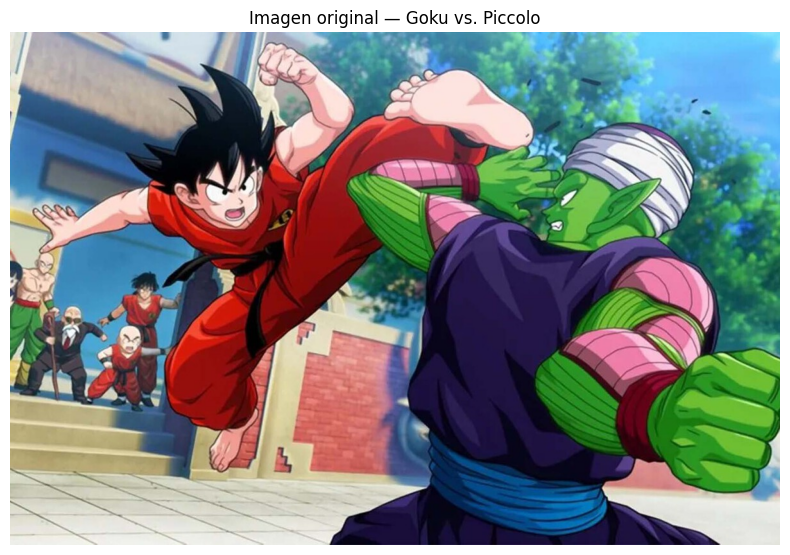

Shape : (800, 1200, 3)  (alto=800px, ancho=1200px, canales=3)
Dtype : uint8  |  Rango: [0, 255]
Píxeles totales: 960,000


In [2]:
try:
    img = plt.imread('goku_vs_piccolo.jpeg')
except (FileNotFoundError, OSError):
    !curl -sL -o goku_vs_piccolo.jpeg "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/goku_vs_piccolo.jpeg"
    img = plt.imread('goku_vs_piccolo.jpeg')

H, W, C = img.shape

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
ax.axis('off')
ax.set_title('Imagen original — Goku vs. Piccolo')
plt.tight_layout()
plt.show()

print(f'Shape : {img.shape}  (alto={H}px, ancho={W}px, canales={C})')
print(f'Dtype : {img.dtype}  |  Rango: [{img.min()}, {img.max()}]')
print(f'Píxeles totales: {H * W:,}')

Antes de implementar K-Means, conviene entender qué forma tienen los datos.

La imagen `(800, 1200, 3)` se "aplana" a una matriz `(960.000, 3)`: cada píxel pasa a ser una muestra con 3 features (R, G, B). Es la misma idea que en TPs anteriores donde se aplanaban espectrogramas o imágenes — se pierde la información espacial (ya no importa dónde estaba cada píxel), pero se gana una representación uniforme donde cada muestra es un punto en $\mathbb{R}^3$.

El espacio de colores es un cubo de lado 256: el eje $x$ es el rojo, el eje $y$ el verde y el eje $z$ el azul. Los 960.000 píxeles de la imagen son 960.000 puntos dentro de ese cubo.

Como visualizar una nube 3D es complicado, se proyectan los píxeles en los tres planos del cubo (RG, RB, GB) para ver dónde se concentran los colores de la imagen.

Imagen original  : (800, 1200, 3)
Píxeles aplanados: (960000, 3)  ← cada fila es una muestra con 3 features (R, G, B)
Tipo             : uint8  |  Rango: [0, 255]

  Píxel      R      G      B
  ─────────────────────────
      0    230    229    225
      1    232    231    227
      2    233    232    228
      3    232    231    227
      4    231    232    227
  ...


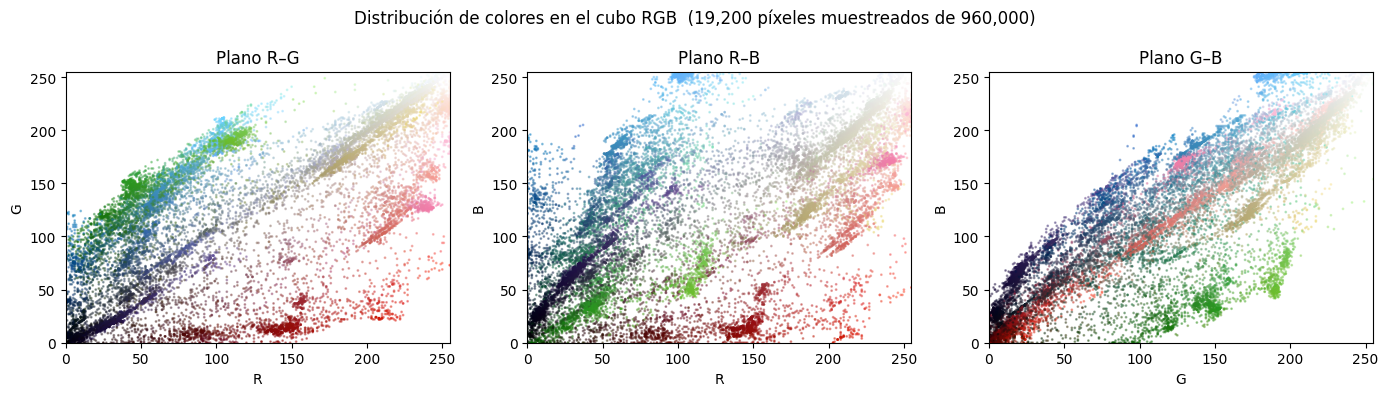

In [3]:
# Aplanar la imagen: (H, W, 3) → (H*W, 3)
pixels = img.reshape(-1, C)        # shape: (960000, 3), valores uint8 [0..255]

print(f'Imagen original  : {img.shape}')
print(f'Píxeles aplanados: {pixels.shape}  ← cada fila es una muestra con 3 features (R, G, B)')
print(f'Tipo             : {pixels.dtype}  |  Rango: [{pixels.min()}, {pixels.max()}]')

# Muestra de los primeros 5 píxeles
print(f"\n{'Píxel':>7}  {'R':>5}  {'G':>5}  {'B':>5}")
print(f"  {'─' * 25}")
for i in range(5):
    print(f"  {i:>5}  {pixels[i, 0]:>5}  {pixels[i, 1]:>5}  {pixels[i, 2]:>5}")
print(f"  ...")

# Subsamplear para graficar (1 de cada 50 píxeles → ~19.200 puntos)
step   = 50
sample = pixels[::step]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs  = [(0, 1, 'R', 'G'), (0, 2, 'R', 'B'), (1, 2, 'G', 'B')]
for ax, (i, j, xi, yj) in zip(axes, pairs):
    ax.scatter(sample[:, i], sample[:, j],
               c=sample / 255.0, s=1, alpha=0.4)
    ax.set_xlabel(xi); ax.set_ylabel(yj)
    ax.set_title(f'Plano {xi}–{yj}')
    ax.set_xlim(0, 255); ax.set_ylim(0, 255)

fig.suptitle(f'Distribución de colores en el cubo RGB  ({len(sample):,} píxeles muestreados de {len(pixels):,})')
plt.tight_layout()
plt.show()

Los tres gráficos son "fotos" del mismo cubo RGB tomadas desde direcciones distintas. En todos aparece una diagonal dominante que corresponde a píxeles con R ≈ G ≈ B — es decir, grises y blancos. Esto refleja que el fondo, el piso y las vendas de Piccolo ocupan una gran porción de la imagen.

Fuera de esa diagonal se distinguen tres nubes de color claramente separadas:
- **Rojo/naranja** (R alto, G y B bajos) → la ropa de Goku
- **Verde** (G alto, R bajo) → la piel de Piccolo
- **Azul/violeta** (B alto, R bajo) → la ropa de Piccolo y el fondo

**Implicancia para K-Means:** el algoritmo va a distribuir los 16 centroides proporcionalmente a la densidad de puntos. Como la zona gris/blanca es la más densa, va a absorber varios centroides. Los colores de los personajes, al ser zonas más pequeñas, recibirán pocos — lo que se va a notar como una leve pérdida de detalle de color en la imagen comprimida.

### Inciso B


El algoritmo K-Means busca representar un conjunto de $N$ muestras con $K$ centroides $\{\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_K\}$, de forma que cada muestra quede lo más cerca posible del centroide que le corresponde. En este caso, cada muestra es un píxel $\mathbf{x} \in \mathbb{R}^3$ con sus componentes R, G, B.

#### Función objetivo

Lo que se minimiza se llama inercia o WCSS (*Within-Cluster Sum of Squares*):

$$J = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2$$

Es la suma de distancias cuadráticas de cada punto a su centroide asignado. Cuanto menor es $J$, mejor representa el conjunto de centroides a los datos.

#### Iteración: dos pasos que se alternan

Una buena forma de entender el algoritmo es pensarlo como una elección y un reposicionamiento. Imaginá que tenés 960.000 personas dispersas por una ciudad y querés abrir 16 centros de salud. Primero todos los habitantes eligen el centro más cercano (paso de asignación). Luego cada centro se muda al centro de gravedad de sus habitantes (paso de actualización). Se repite hasta que los centros ya no tienen a dónde moverse.

Cada iteración procesa todos los datos en bloque: primero se asignan los $N$ píxeles de una sola vez (los centroides no se mueven todavía), y recién después se actualizan los $K$ centroides. No es píxel a píxel, sino una ronda completa de votación seguida de una ronda completa de reposicionamiento.

**1. Asignación:** con los centroides fijos, cada píxel elige el centroide más cercano:

$$k^*(\mathbf{x}) = \arg\min_k \|\mathbf{x} - \boldsymbol{\mu}_k\|^2$$

Cada píxel pertenece a exactamente un cluster. El espacio RGB queda dividido en $K$ zonas (una especie de teselado del cubo).

**2. Actualización:** con las asignaciones fijas, cada centroide se mueve al promedio de sus píxeles asignados:

$$\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{\mathbf{x} \in C_k} \mathbf{x}$$

Esto es el punto que minimiza $J$ para ese cluster con asignaciones fijas, lo que se verifica derivando e igualando a cero:

$$\frac{\partial J}{\partial \boldsymbol{\mu}_k} = -2\sum_{\mathbf{x} \in C_k}(\mathbf{x} - \boldsymbol{\mu}_k) = 0 \implies \boldsymbol{\mu}_k = \frac{1}{|C_k|}\sum_{\mathbf{x} \in C_k}\mathbf{x}$$

#### Convergencia

Cada paso solo puede bajar o mantener $J$, nunca subirlo: la asignación elige el mínimo para cada punto, y la actualización mueve cada centroide a su óptimo analítico. Como $J \geq 0$, el algoritmo siempre converge. En la práctica se detiene cuando el desplazamiento máximo de cualquier centroide entre iteraciones cae por debajo de una tolerancia:

$$\text{shift} = \max_k \|\boldsymbol{\mu}_k^{\text{nuevo}} - \boldsymbol{\mu}_k^{\text{viejo}}\| < \text{tol}$$

#### Mínimos locales e inicialización: K-Means++

K-Means converge, pero no necesariamente al mínimo global de $J$ puede quedar atrapado en un mínimo local dependiendo de la inicialización. Un caso extremo es que dos centroides arranquen muy cerca entre sí y terminen convergiendo a la misma zona: uno de los dos queda sin píxeles asignados (cluster vacío), desperdiciando uno de los 16 colores disponibles.

La solución estándar a este problema es **K-Means++**: en vez de elegir los $K$ centroides iniciales completamente al azar, se inicializan de forma espaciada. El primer centroide se elige al azar. Cada siguiente se elige con probabilidad proporcional a $d^2$, la distancia cuadrada al centroide ya elegido más cercano:

$$P(\mathbf{x}) \propto \min_k \|\mathbf{x} - \boldsymbol{\mu}_k\|^2$$

Esto fuerza a que los centroides iniciales queden distribuidos por distintas zonas del espacio, reduciendo drásticamente la probabilidad de colisión. La implementación aquí usa inicialización aleatoria simple con `random_state=42` para reproducibilidad, en la práctica, si se usa K-Means se realizan varias iteraciones aleatorias del modelo con los mismos datos y después se elije el que tiene el mínimo local más chico.

#### Representación de los centroides

Cada centroide es un vector de la misma dimensión que los datos. En este caso $\boldsymbol{\mu}_k \in \mathbb{R}^3$, con sus tres componentes representando un color en el espacio RGB. Los $K=16$ centroides forman una matriz de $16 \times 3$: cada fila es un color aprendido, y la tabla completa es la paleta de 16 colores que usará la imagen comprimida.


Píxeles a clusterizar : 960,000  (800×1200)
Entrenando KMeans con K=16 ...
  Convergió en 92 iteraciones  (shift = 7.26e-05)


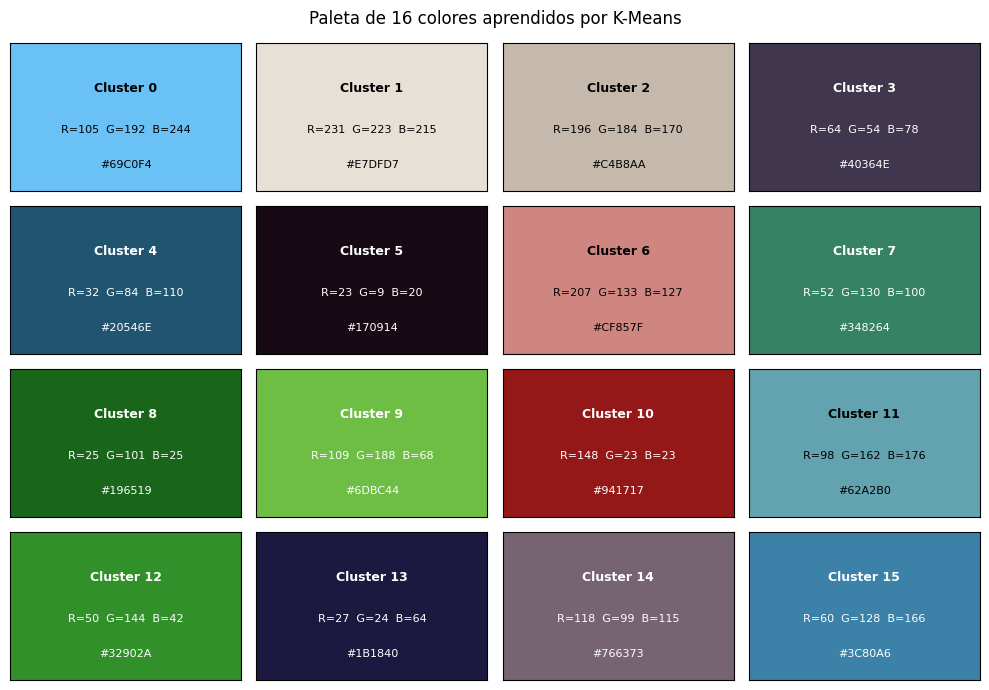

In [4]:
class Kmeans:
    '''K-Means implementado desde cero usando solo NumPy.'''

    def __init__(self, n_clusters=16, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters       = n_clusters
        self.max_iter         = max_iter
        self.tol              = tol
        self.random_state     = random_state
        self.cluster_centers_ = None

    def fit(self, X):
        '''Entrena el modelo sobre la matriz X (n_muestras, n_features).'''
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(len(X), size=self.n_clusters, replace=False)
        self.cluster_centers_ = X[idx].astype(float).copy()

        for it in range(self.max_iter):
            labels = self._assign(X)
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k)
                else self.cluster_centers_[k]
                for k in range(self.n_clusters)
            ])
            shift = np.max(np.linalg.norm(new_centers - self.cluster_centers_, axis=1))
            self.cluster_centers_ = new_centers
            if shift < self.tol:
                print(f'  Convergió en {it + 1} iteraciones  (shift = {shift:.2e})')
                break
        else:
            print(f'  Máximo de iteraciones alcanzado ({self.max_iter})')
        return self

    def _assign(self, X):
        '''Asigna cada muestra al centroide más cercano (||x-mu||^2 vectorizado).'''
        X_sq   = np.sum(X ** 2, axis=1, keepdims=True)          # (n, 1)
        C_sq   = np.sum(self.cluster_centers_ ** 2, axis=1)      # (k,)
        cross  = X @ self.cluster_centers_.T                     # (n, k)
        dists2 = X_sq + C_sq - 2 * cross                        # (n, k)
        return np.argmin(dists2, axis=1)

    def predict(self, X):
        '''Devuelve el índice del cluster más cercano para cada muestra.'''
        return self._assign(X)


# ── Preparar datos de la imagen ─────────────────────────────────────────────
X_img = img.reshape(-1, C).astype(float) / 255.0    # (H*W, 3), rango [0, 1]

print(f'Píxeles a clusterizar : {X_img.shape[0]:,}  ({H}×{W})')
print(f'Entrenando KMeans con K=16 ...')

km_img = Kmeans(n_clusters=16, max_iter=300, tol=1e-4, random_state=42)
km_img.fit(X_img)

# ── Mostrar paleta aprendida ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(10, 7))
for i, (c, ax) in enumerate(zip(km_img.cluster_centers_, axes.flat)):
    rgb_255  = (c * 255).astype(int)
    hex_code = '#{:02X}{:02X}{:02X}'.format(*rgb_255)
    ax.set_facecolor(c)
    ax.set_xticks([]); ax.set_yticks([])
    txt_color = 'white' if c.mean() < 0.5 else 'black'
    ax.text(0.5, 0.70, f'Cluster {i}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=9, fontweight='bold', color=txt_color)
    ax.text(0.5, 0.42, f'R={rgb_255[0]}  G={rgb_255[1]}  B={rgb_255[2]}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8, color=txt_color)
    ax.text(0.5, 0.18, hex_code,
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8, color=txt_color)

fig.suptitle('Paleta de 16 colores aprendidos por K-Means', fontsize=12)
plt.tight_layout()
plt.show()


Estos dos parámetros, `tol` y `max_iter`, son decisiones de arbitrarias, no matemáticas. No hay una fórmula que indique cuáles son los "correctos".

- **`tol = 1e-4`**: los datos están normalizados a $[0, 1]$, por lo que un desplazamiento de $0.0001$ equivale a $0.0001 \times 255 \approx 0.025$ niveles de color, imperceptible para el ojo humano. Seguir iterando más allá de ese punto no mejoraría la imagen, ni daría más información útil.

- **`max_iter = 300`**: porque en casos raros, K-Means puede oscilar o converger muy lentamente. Si el algoritmo llega a este límite sin cumplir la tolerancia, es una señal de alerta: datos mal escalados, $K$ demasiado grande, o mínimo local problemático.

El entrenamiento convergió en 92 iteraciones con un shift final de $7.26 \times 10^{-5} < 10^{-4}$, lo que indica que paró por tolerancia y no por límite de iteraciones señal de que el algoritmo encontró una solución estable.

Los 16 centroides aprendidos se pueden asociar con zonas concretas de la imagen, sin que el algoritmo haya recibido ninguna información sobre el contenido visual:

| Clusters | Color aproximado | Zona de la imagen |
|----------|-----------------|-------------------|
| 1, 2 | gris claro / beige | fondo, piso, vendas de Piccolo |
| 10 | rojo/naranja | ropa de Goku |
| 6 | salmón | piel de Goku |
| 8, 9, 12 | verde oscuro/medio/claro | piel de Piccolo (3 centroides) |
| 7 | verde azulado | sombras de Piccolo |
| 0 | azul cielo | fondo azulado |
| 3, 13 | violeta/negro | ropa oscura de Piccolo |
| 5 | casi negro | sombras profundas |

Esto confirma lo observado en el Inciso A: la zona gris absorbió varios centroides por ser la más densa, y la piel de Piccolo (verde) atrajo tres centroides distintos a pesar de ser una zona pequeña, porque estaba suficientemente separada del resto del cubo RGB como para justificar esa subdivisión.


### Inciso C

Con los centroides aprendidos, la compresión es directa: cada uno de los 960.000 píxeles se reemplaza por el color del centroide al que fue asignado. En lugar de guardar el color exacto de cada píxel, se guarda únicamente su etiqueta el índice del centroide más cercano, un número entre 0 y 15.

Para reconstruir la imagen basta con hacer `centroides[etiquetas]`: una sola indexación que mapea cada etiqueta a su color y devuelve la imagen comprimida en la misma forma $(H, W, 3)$ que la original.


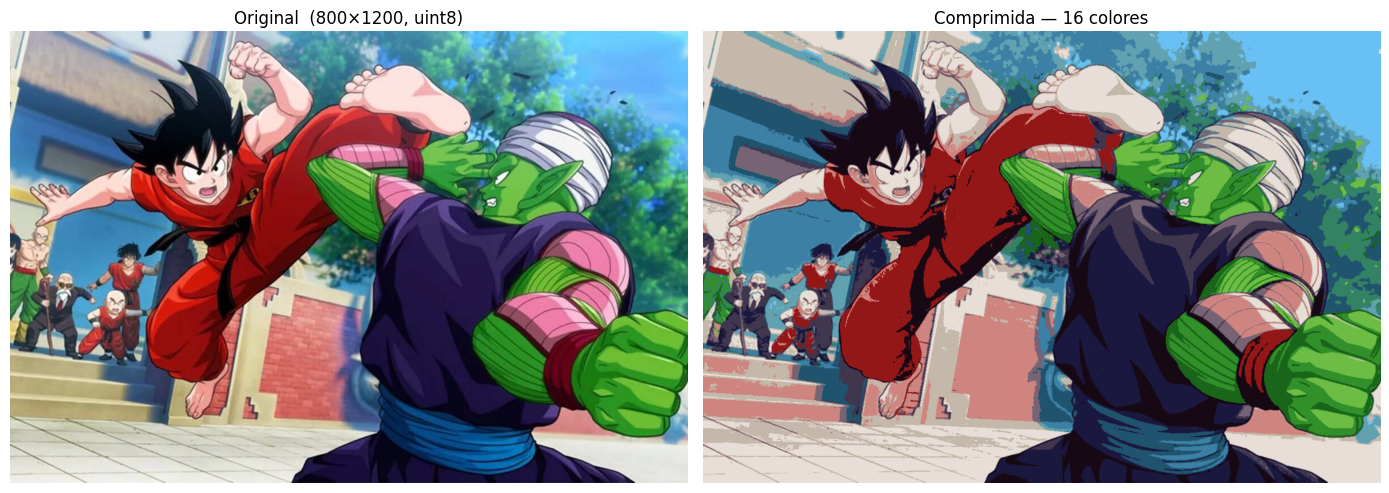

In [5]:
labels_img     = km_img.predict(X_img)
img_compressed = (km_img.cluster_centers_[labels_img] * 255).astype(np.uint8).reshape(H, W, C)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f'Original  ({H}×{W}, {img.dtype})')
axes[1].imshow(img_compressed)
axes[1].axis('off')
axes[1].set_title('Comprimida — 16 colores')
plt.tight_layout()
plt.show()

La imagen comprimida conserva una calidad visual notable con solo 16 colores. Las zonas de color uniforme — la ropa roja de Goku, la piel verde de Piccolo, el fondo azul — se reproducen casi perfectamente porque son exactamente las regiones donde K-Means concentró sus centroides.

La pérdida de calidad se hace visible en las transiciones y gradientes: los tonos de piel de Goku se ven más planos, el fondo pierde parte del degradado de luz, y las sombras quedan cuantizadas en escalones bruscos. Esto es una consecuencia directa de que la paleta tiene solo 16 valores posibles: donde el original tenía cientos de tonos intermedios, la imagen comprimida debe elegir el más cercano de esos 16.

En otras palabras, K-Means "invirtió bien" sus 16 centroides donde había más densidad de píxeles, y ahí la imagen se ve bien. El costo se paga en las zonas de transición, que son siempre las más difíciles de representar con pocos colores.


### Inciso D


La compresión por K-Means no solo reduce la cantidad de colores visibles — también reduce el espacio de almacenamiento. El razonamiento es el siguiente:

- **Imagen original**: cada píxel necesita 3 canales × 8 bits = 24 bits.
- **Imagen comprimida**: en lugar de guardar los 24 bits de cada píxel, alcanza con guardar la etiqueta del centroide al que fue asignado. Con $K=16$ centroides hacen falta $\lceil \log_2(16) \rceil = 4$ bits por píxel. Adicionalmente se guarda la tabla de centroides (los 16 colores aprendidos), pero su tamaño es despreciable frente al total.

$$\text{bits\_original} = H \times W \times 3 \times 8$$

$$\text{bits\_comprimida} = \underbrace{H \times W \times \lceil \log_2 K \rceil}_{\text{mapa de etiquetas}} + \underbrace{K \times 3 \times 8}_{\text{tabla centroides}}$$

Donde:

- H (*Height*)= 800 $→$ alto en píxeles

- W (*Widht*)= 1200 $→$ ancho en píxeles

In [6]:
K = km_img.n_clusters    # 16

bits_antes        = H * W * C * 8
bits_x_etiqueta   = int(np.ceil(np.log2(K)))       # log2(16) = 4
bits_etiquetas    = H * W * bits_x_etiqueta
bits_centroides   = K * C * 8
bits_despues      = bits_etiquetas + bits_centroides
ratio             = bits_antes / bits_despues

print('─── Imagen original ──────────────────────────────────────')
print(f'  Dimensiones : {H} × {W} × {C} canales')
print(f'  Bits/pixel  : {C} canales × 8 bits = {C * 8} bits')
print(f'  Total       : {bits_antes:,} bits  ({bits_antes / 8 / 1024:.1f} KB)')
print()
print('─── Imagen comprimida (K=16) ─────────────────────────────')
print(f'  Mapa de etiquetas  : {H}×{W} × {bits_x_etiqueta} bits = {bits_etiquetas:,} bits')
print(f'  Tabla de centroides: {K} × {C} × 8 = {bits_centroides} bits  (overhead pequeño)')
print(f'  Total              : {bits_despues:,} bits  ({bits_despues / 8 / 1024:.1f} KB)')
print()
print(f'  Factor de compresión : {ratio:.1f}×  (reducción del {100 * (1 - 1/ratio):.1f}%)')

─── Imagen original ──────────────────────────────────────
  Dimensiones : 800 × 1200 × 3 canales
  Bits/pixel  : 3 canales × 8 bits = 24 bits
  Total       : 23,040,000 bits  (2812.5 KB)

─── Imagen comprimida (K=16) ─────────────────────────────
  Mapa de etiquetas  : 800×1200 × 4 bits = 3,840,000 bits
  Tabla de centroides: 16 × 3 × 8 = 384 bits  (overhead pequeño)
  Total              : 3,840,384 bits  (468.8 KB)

  Factor de compresión : 6.0×  (reducción del 83.3%)


El resultado es contundente. La imagen original ocupa 2812.5 KB (24 bits por píxel). La comprimida ocupa 468.8 KB (4 bits por píxel más la tabla de 16 colores, cuyo overhead de 384 bits es completamente despreciable frente a los 3.8 millones de bits del mapa de etiquetas).

Eso da un factor de compresión de 6×, la imagen pesa 6 veces menos, con una reducción del 83.3% del espacio original. Y como se vio en el Inciso C, la calidad visual sigue siendo alta.

La clave está en $\log_2 K$: con $K=16$ alcanza con 4 bits por píxel en lugar de 24. Si se usara $K=256$ la calidad sería casi indistinguible del original, pero necesitaría 8 bits por píxel, igual que el original sin comprimir. El valor $K=16$ es el punto intermedio que logra una compresión agresiva a cambio de una pérdida de calidad aceptable.


## Punto 2: Caracterización de Consumo Eléctrico


En la Parte 1 se aplicó K-Means a píxeles de una imagen — puntos en $\mathbb{R}^3$. Acá se aplica exactamente el mismo algoritmo a un problema completamente distinto: señales de consumo eléctrico diario de 90 hogares de Buenos Aires.

La diferencia clave es la dimensión de los datos. Cada muestra ya no es un punto en $\mathbb{R}^3$ sino una curva de 24 horas — es decir, un punto en $\mathbb{R}^{24}$. El algoritmo no "sabe" nada de esto: recibirá una matriz de $90 \times 24$ y buscará 3 centroides que minimicen la inercia, igual que antes. Lo que cambia es la interpretación: en lugar de colores, los centroides van a ser perfiles típicos de consumo, curvas que resumen el comportamiento de cada grupo de hogares a lo largo del día.


### Inciso A

Se carga el dataset `consumo_electrico.npy` y se exploran sus características antes de aplicar K-Means.

In [14]:

# ── Cargar datos ─────────────────────────────────────────────────────────────
try:
    consumo = np.load('consumo_electrico.npy')
except FileNotFoundError:
    !curl -sL -o consumo_electrico.npy "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/consumo_electrico.npy"
    consumo = np.load('consumo_electrico.npy')

N, T  = consumo.shape
horas = np.arange(T)

print(f'Shape  : {consumo.shape}  ({N} hogares × {T} horas)')
print(f'Dtype  : {consumo.dtype}')
print(f'Rango  : [{consumo.min():.3f}, {consumo.max():.3f}]')


Shape  : (90, 24)  (90 hogares × 24 horas)
Dtype  : float64
Rango  : [-0.233, 2.755]


El array tiene forma `(90, 24)`: 90 hogares, cada uno descripto por 24 valores que representan su consumo eléctrico hora a hora a lo largo de un día. En términos de aprendizaje automático, cada hogar es una muestra y cada hora es un feature, igual que en el Punto 1 cada píxel era una muestra con 3 features (R, G, B), acá cada hogar es una muestra con 24 features.

El rango $[-0.233, \ 2.755]$ indica que los datos ya fueron normalizados (no están en kWh sino en unidades arbitrarias centradas). El mínimo ligeramente negativo refleja ruido de medición o fluctuaciones en torno al cero.


A continuación, se grafican las series en función del tiempo.

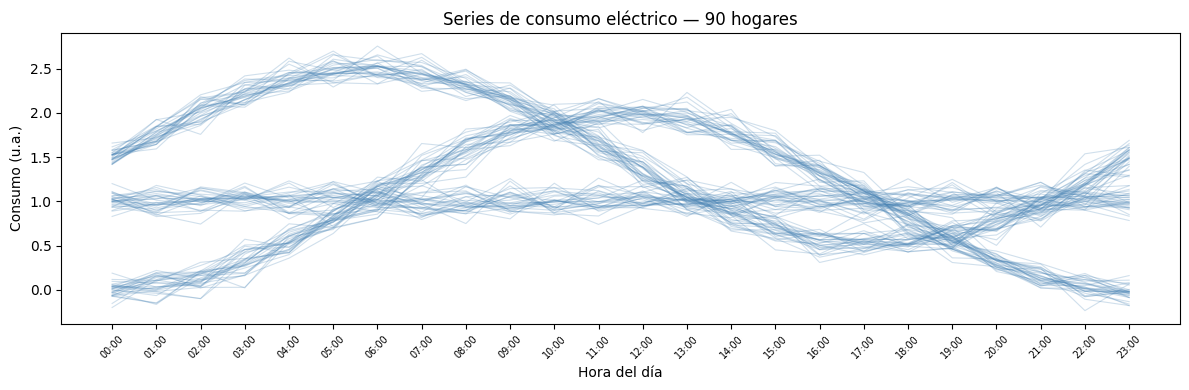

In [15]:
# ── Visualización de todas las series ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for serie in consumo:
    ax.plot(horas, serie, color='steelblue', alpha=0.25, linewidth=0.8)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Consumo (u.a.)')
ax.set_title(f'Series de consumo eléctrico — {N} hogares')
ax.set_xticks(horas)
ax.set_xticklabels([f'{h:02d}:00' for h in horas], rotation=45, fontsize=7)
plt.tight_layout()
plt.show()




El gráfico revela que las 90 curvas no se mezclan uniformemente desde la primera hora ya se separan en bandas distinguibles:

- **Grupo bajo** (~0 a medianoche): hogares que prácticamente no consumen mientras duermen. Se activan gradualmente a partir de las 06:00 y alcanzan su pico al mediodía o tarde.
- **Grupo alto** (~1.5 a medianoche, sube hasta ~2.5 hacia las 04:00–05:00): hogares con consumo nocturno elevado — posiblemente calefacción eléctrica, turno nocturno, o equipos que trabajan de madrugada. A partir del amanecer el consumo cae.
- **Grupo intermedio** (~1.0 a medianoche): perfil más plano, sin picos pronunciados ni caídas bruscas.

A las 00:00 ya se ven las tres bandas claramente separadas. Esta separación visible anticipa que K-Means con $K=3$ va a encontrar clusters bien definidos.


### Inciso B

Se reutiliza la clase `Kmeans` del Punto 1 sin ninguna modificación, la única diferencia es que ahora cada muestra es un vector de 24 dimensiones en lugar de 3. El algoritmo no distingue: recibe una matriz de $90 \times 24$, inicializa 3 centroides y alterna los mismos dos pasos de siempre.

Con $K=3$ se busca confirmar la estructura visual observada en el Inciso A: que los 90 hogares se organizan en tres perfiles de consumo diferenciados.


In [8]:
# ── Entrenar K-Means con K=3 ─────────────────────────────────────────────────
# Cada hogar es una muestra de 24 features (una por hora)
# La clase Kmeans es la misma que en el Punto 1

print(f'Muestras a clusterizar : {N}  (hogares)')
print(f'Features por muestra   : {T}  (horas del día)')
print(f'Entrenando KMeans con K=3 ...\n')

km_consumo = Kmeans(n_clusters=3, max_iter=300, tol=1e-4, random_state=42)
km_consumo.fit(consumo)

labels_consumo = km_consumo.predict(consumo)

print(f'\nDistribución de hogares por cluster:')
for k in range(3):
    print(f'  Cluster {k}: {np.sum(labels_consumo == k):>3} hogares')


Muestras a clusterizar : 90  (hogares)
Features por muestra   : 24  (horas del día)
Entrenando KMeans con K=3 ...

  Convergió en 2 iteraciones  (shift = 0.00e+00)

Distribución de hogares por cluster:
  Cluster 0:  30 hogares
  Cluster 1:  30 hogares
  Cluster 2:  30 hogares


El resultado es llamativo en dos sentidos.

**Convergencia en 2 iteraciones con shift = 0**: el algoritmo encontró la solución en la primera reasignación. Esto indica que los tres grupos están tan bien separados en $\mathbb{R}^{24}$ que los centroides iniciales (elegidos al azar entre los 90 hogares) ya cayeron cada uno dentro de su cluster natural. En la segunda iteración, los centroides se movieron a la media de sus hogares asignados y en la siguiente vuelta ningún hogar cambió de cluster con shift exactamente cero, convergencia perfecta. Es la señal más clara posible de que la estructura en los datos es muy pronunciada.

**30 hogares por cluster exacto**: los tres grupos tienen exactamente el mismo tamaño. Esto no es coincidencia, el dataset fue construido con 30 hogares de cada perfil. Que K-Means los recupere perfectamente con sólo 2 iteraciones confirma que los perfiles son genuinamente distintos y bien separados en el espacio de señales.


### Inciso C

Con las etiquetas asignadas, se vuelve a graficar el mismo conjunto de series del Inciso A pero ahora coloreando cada hogar según su cluster. Esto permite verificar visualmente que los grupos identificados por K-Means corresponden efectivamente a las tres bandas que se intuían a ojo.


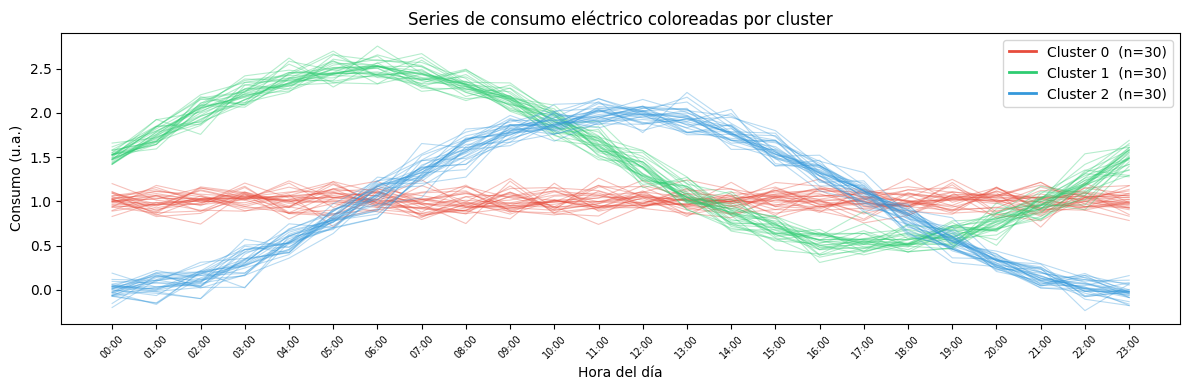

In [9]:
# ── Series coloreadas por cluster ─────────────────────────────────────────────
colors = ['#E74C3C', '#2ECC71', '#3498DB']   # rojo, verde, azul

fig, ax = plt.subplots(figsize=(12, 4))
for k, color in enumerate(colors):
    for serie in consumo[labels_consumo == k]:
        ax.plot(horas, serie, color=color, alpha=0.35, linewidth=0.8)
    ax.plot([], [], color=color, linewidth=2, label=f'Cluster {k}  (n={np.sum(labels_consumo == k)})')

ax.set_xlabel('Hora del día')
ax.set_ylabel('Consumo (u.a.)')
ax.set_title('Series de consumo eléctrico coloreadas por cluster')
ax.set_xticks(horas)
ax.set_xticklabels([f'{h:02d}:00' for h in horas], rotation=45, fontsize=7)
ax.legend()
plt.tight_layout()
plt.show()



El color confirma lo que se veía a ojo en el Inciso A, los tres grupos están perfectamente separados sin ninguna superposición. Los valores del eje Y están en u.a. (unidades arbitrarias): los datos fueron normalizados y ya no representan kWh directamente, sino una escala relativa que preserva la forma de las curvas.

- **Cluster 0 (rojo) — perfil plano**: consumo constante alrededor de 1.0 u.a. durante las 24 horas. Sin picos ni caídas relevantes. Probablemente hogares con consumo base estable, electrodomésticos encendidos continuamente, poca variación de actividad.
- **Cluster 1 (verde) — perfil nocturno**: arranca alto (~1.5 u.a.) a medianoche, sube hasta ~2.5 u.a. entre las 04:00 y 05:00, y cae progresivamente durante el día hasta valores bajos al anochecer. Perfil compatible con calefacción eléctrica intensa durante la madrugada o equipos industriales en turno nocturno.
- **Cluster 2 (azul) — perfil diurno**: arranca en casi 0 u.a. a medianoche (hogares dormidos sin consumo), sube abruptamente desde las 07:00, alcanza su pico entre las 10:00 y 13:00 (~2.0 u.a.), y vuelve a caer al final del día. Perfil típico de un hogar con actividad diurna: cocción, iluminación, electrodomésticos durante las horas activas.

La separación es tan clara que las series de un cluster apenas se solapan con las de otro, exactamente lo que predijo la convergencia en 2 iteraciones del Inciso B.


### Inciso D

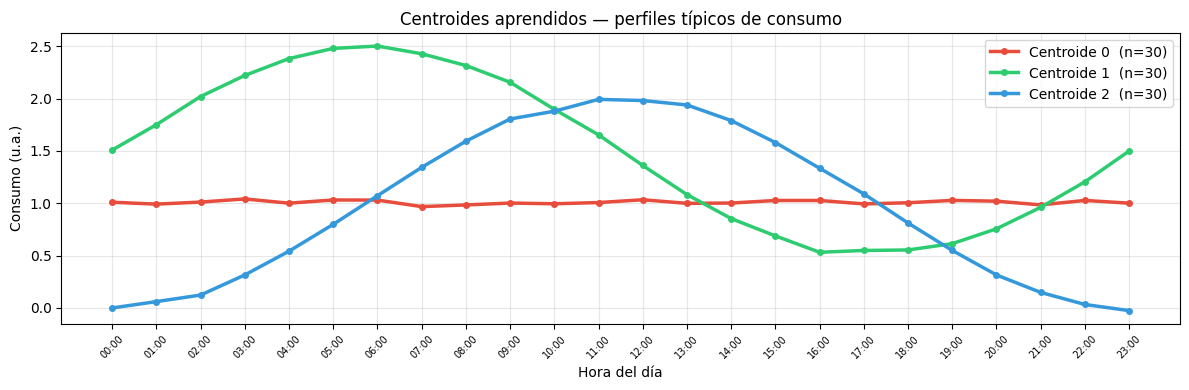

In [10]:
# ── Graficar los 3 centroides ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for k, (centroide, color) in enumerate(zip(km_consumo.cluster_centers_, colors)):
    ax.plot(horas, centroide, color=color, linewidth=2.5,
            marker='o', markersize=4,
            label=f'Centroide {k}  (n={np.sum(labels_consumo == k)})')

ax.set_xlabel('Hora del día')
ax.set_ylabel('Consumo (u.a.)')
ax.set_title('Centroides aprendidos — perfiles típicos de consumo')
ax.set_xticks(horas)
ax.set_xticklabels([f'{h:02d}:00' for h in horas], rotation=45, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
